17464789/17464789 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step

Training RNN model...

Epoch 1/3


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


391/391 ━━━━━━━━━━━━━━━━━━━━ 30s 72ms/step - accuracy: 0.6630 - loss: 0.6027 - val_accuracy: 0.7816 - val_loss: 0.4770
Epoch 2/3
391/391 ━━━━━━━━━━━━━━━━━━━━ 30s 76ms/step - accuracy: 0.8173 - loss: 0.4128 - val_accuracy: 0.7702 - val_loss: 0.4776
Epoch 3/3
391/391 ━━━━━━━━━━━━━━━━━━━━ 30s 76ms/step - accuracy: 0.8507 - loss: 0.3502 - val_accuracy: 0.8095 - val_loss: 0.5263

Training LSTM model...

Epoch 1/3
391/391 ━━━━━━━━━━━━━━━━━━━━ 83s 209ms/step - accuracy: 0.8118 - loss: 0.4082 - val_accuracy: 0.8551 - val_loss: 0.3463
Epoch 2/3
391/391 ━━━━━━━━━━━━━━━━━━━━ 84s 216ms/step - accuracy: 0.9079 - loss: 0.2387 - val_accuracy: 0.8652 - val_loss: 0.3184
Epoch 3/3
391/391 ━━━━━━━━━━━━━━━━━━━━ 81s 206ms/step - accuracy: 0.9314 - loss: 0.1830 - val_accuracy: 0.8680 - val_loss: 0.3366

Training GRU model...

Epoch 1/3
391/391 ━━━━━━━━━━━━━━━━━━━━ 83s 207ms/step - accuracy: 0.7748 - loss: 0.4553 - val_accuracy: 0.8594 - val_loss: 0.3338
Epoch 2/3
391/391 ━━━━━━━━━━━━━━━━━━━━ 88s 224ms/step 

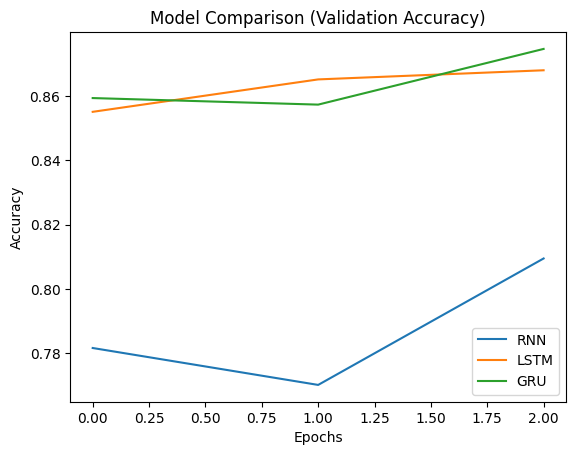

In [ ]:

import tensorflow as tf
from tensorflow.keras.datasets import imdb
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras import layers, models
import matplotlib.pyplot as plt


vocab_size = 10000
max_len = 200

(x_train, y_train), (x_test, y_test) = imdb.load_data(num_words=vocab_size)


x_train = pad_sequences(x_train, maxlen=max_len)
x_test = pad_sequences(x_test, maxlen=max_len)


def build_model(model_type):
    model = models.Sequential()

    model.add(layers.Embedding(vocab_size, 128, input_length=max_len))

    if model_type == "RNN":
        model.add(layers.SimpleRNN(64))
    elif model_type == "LSTM":
        model.add(layers.LSTM(64))
    elif model_type == "GRU":
        model.add(layers.GRU(64))

    model.add(layers.Dense(1, activation='sigmoid'))

    model.compile(
        optimizer='adam',
        loss='binary_crossentropy',
        metrics=['accuracy']
    )

    return model


models_dict = {}
history_dict = {}

for m in ["RNN", "LSTM", "GRU"]:
    print(f"\nTraining {m} model...\n")
    model = build_model(m)

    history = model.fit(
        x_train, y_train,
        epochs=3,
        batch_size=64,
        validation_data=(x_test, y_test)
    )

    models_dict[m] = model
    history_dict[m] = history

for m in models_dict:
    loss, acc = models_dict[m].evaluate(x_test, y_test)
    print(f"{m} Test Accuracy: {acc:.4f}")

plt.figure()

for m in history_dict:
    plt.plot(history_dict[m].history['val_accuracy'], label=m)

plt.title("Model Comparison (Validation Accuracy)")
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.legend()
plt.show()